<a href="https://colab.research.google.com/github/SANGRAMLEMBE/MTech/blob/main/Deep_Neural_Network/Practical/assignment/01_convolution_fundamentals.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 1: Convolution Fundamentals (1D)

**Course:** 21CSE558T - Deep Neural Network Architectures  
**Module 4:** CNNs - Practical Session  
**Date:** Saturday, November 1, 2025  
**Duration:** 30 minutes  
**Objective:** Understand convolution operation from scratch using 1D signals

---

## Why Start with 1D?

- 🎯 **Simpler to visualize** - Just a line, not a matrix
- 🎯 **Same math** - 1D and 2D convolution work the same way
- 🎯 **Build intuition** - Understand kernels, stride, padding first
- 🎯 **Real applications** - Audio, time series, ECG signals

**By the end:** You'll understand HOW convolution works, not just use it!

In [1]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import HTML, display
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 4)

print("✅ Libraries loaded successfully!")
print(f"NumPy version: {np.__version__}")

✅ Libraries loaded successfully!
NumPy version: 2.0.2


---

## Part 1: What is Convolution?

**Simple Analogy:**  
Imagine you're looking at a signal through a **sliding window**. At each position, you:
1. Multiply the signal values by the window values (element-wise)
2. Sum all the products
3. Move the window to the next position

**That's convolution!**

```
Signal:  [1, 2, 3, 4, 5]
Kernel:  [0.5, 1, 0.5]

Position 0: 1*0.5 + 2*1 + 3*0.5 = 4.0
Position 1: 2*0.5 + 3*1 + 4*0.5 = 6.0
Position 2: 3*0.5 + 4*1 + 5*0.5 = 8.0

Output: [4.0, 6.0, 8.0]
```

In [2]:
# Let's implement 1D convolution from scratch!

def conv1d_simple(signal, kernel, stride=1, padding=0):
    """
    1D convolution from scratch

    Args:
        signal: Input 1D array
        kernel: 1D filter/kernel
        stride: Step size for sliding window
        padding: Number of zeros to pad on each side

    Returns:
        output: Convolved signal
    """
    # Add padding
    if padding > 0:
        signal = np.pad(signal, (padding, padding), mode='constant')

    # Calculate output size
    output_size = (len(signal) - len(kernel)) // stride + 1
    output = np.zeros(output_size)

    # Perform convolution
    for i in range(output_size):
        start_idx = i * stride
        end_idx = start_idx + len(kernel)
        # Element-wise multiplication and sum
        output[i] = np.sum(signal[start_idx:end_idx] * kernel)

    return output

print("✅ 1D Convolution function defined!")

✅ 1D Convolution function defined!


---

## Part 2: First Convolution Example

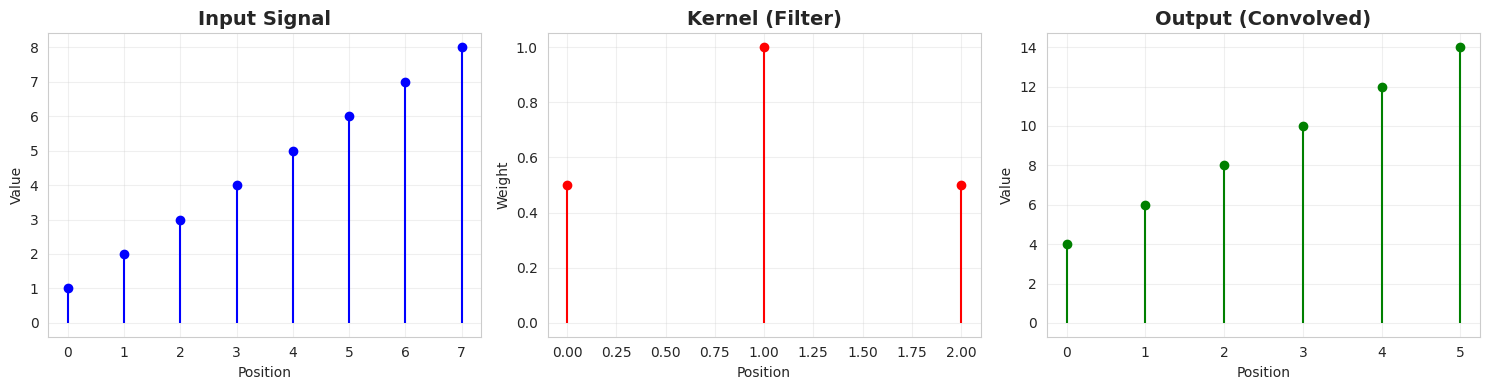


📊 Results:
Input length:  8
Kernel length: 3
Output length: 6

Output formula: (Input_size - Kernel_size) + 1 = (8 - 3) + 1 = 6


In [3]:
# Create a simple signal
signal = np.array([1, 2, 3, 4, 5, 6, 7, 8])

# Create a simple kernel (moving average)
kernel = np.array([0.5, 1, 0.5])

# Perform convolution
output = conv1d_simple(signal, kernel)

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Original signal
axes[0].stem(signal, basefmt=' ', linefmt='b-', markerfmt='bo')
axes[0].set_title('Input Signal', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Position')
axes[0].set_ylabel('Value')
axes[0].grid(True, alpha=0.3)

# Kernel
axes[1].stem(kernel, basefmt=' ', linefmt='r-', markerfmt='ro')
axes[1].set_title('Kernel (Filter)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Position')
axes[1].set_ylabel('Weight')
axes[1].grid(True, alpha=0.3)

# Output
axes[2].stem(output, basefmt=' ', linefmt='g-', markerfmt='go')
axes[2].set_title('Output (Convolved)', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Position')
axes[2].set_ylabel('Value')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n📊 Results:")
print(f"Input length:  {len(signal)}")
print(f"Kernel length: {len(kernel)}")
print(f"Output length: {len(output)}")
print(f"\nOutput formula: (Input_size - Kernel_size) + 1 = ({len(signal)} - {len(kernel)}) + 1 = {len(output)}")

---

## Part 3: Effect of Different Kernels

Different kernels detect different patterns:
- **Smoothing kernel**: Averages nearby values (removes noise)
- **Edge detection kernel**: Finds sudden changes
- **Sharpening kernel**: Enhances differences

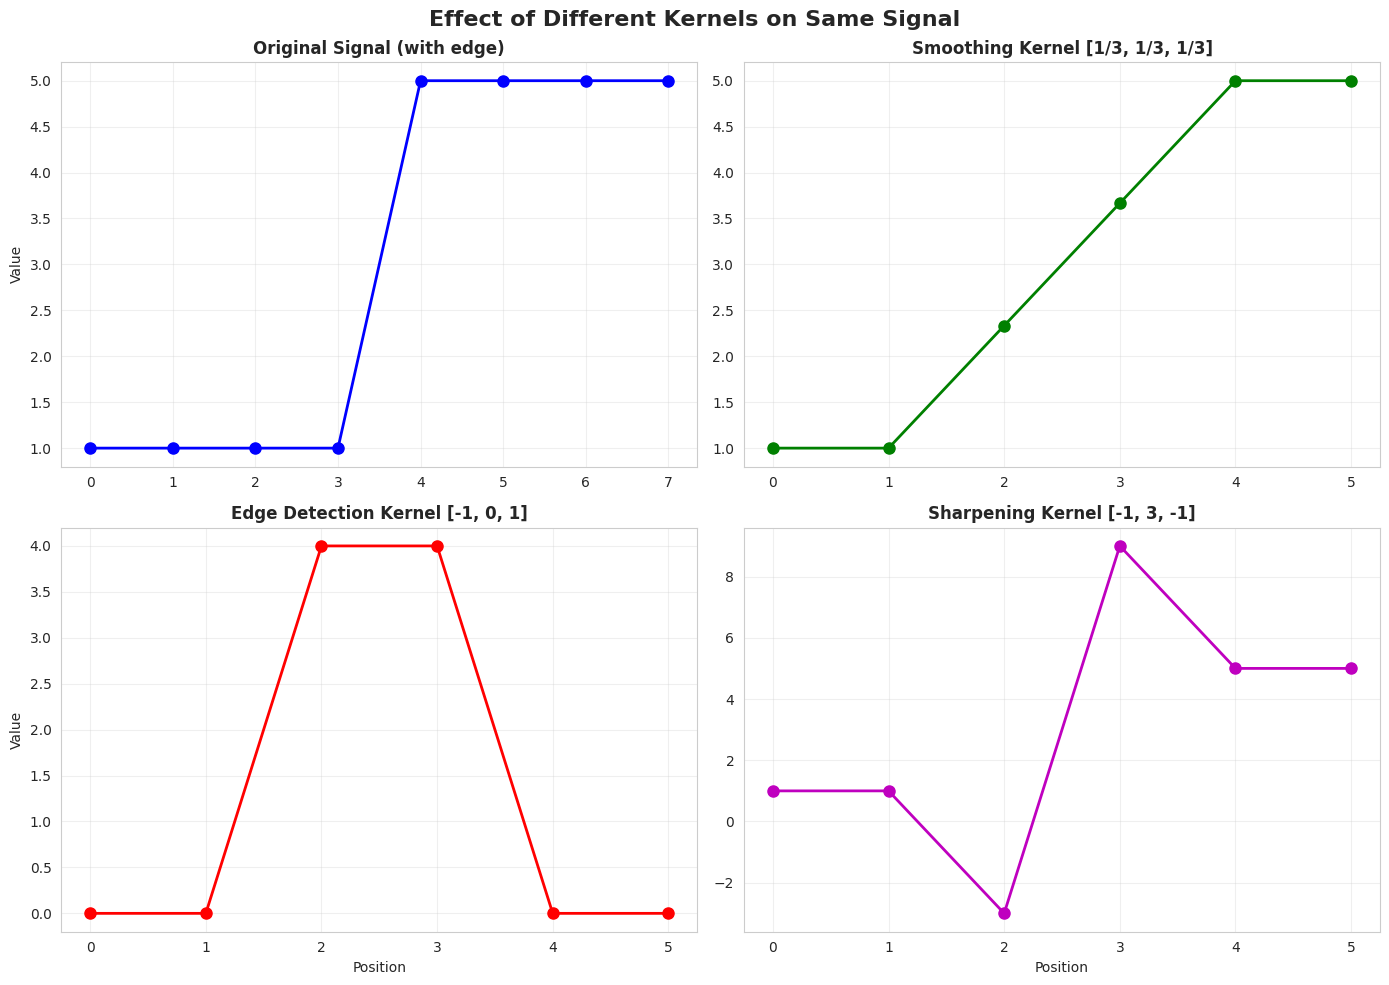


🔍 Observations:
✅ Smoothing: Softens the edge (blurs)
✅ Edge Detection: Peak at edge location!
✅ Sharpening: Emphasizes the transition


In [4]:
# Create a signal with a step (edge)
signal_with_edge = np.array([1, 1, 1, 1, 5, 5, 5, 5])

# Different kernels
kernel_smooth = np.array([1/3, 1/3, 1/3])  # Average
kernel_edge = np.array([-1, 0, 1])         # Edge detector
kernel_sharpen = np.array([-1, 3, -1])     # Sharpening

# Apply all kernels
output_smooth = conv1d_simple(signal_with_edge, kernel_smooth)
output_edge = conv1d_simple(signal_with_edge, kernel_edge)
output_sharpen = conv1d_simple(signal_with_edge, kernel_sharpen)

# Visualize
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Original
axes[0, 0].plot(signal_with_edge, 'b-o', linewidth=2, markersize=8)
axes[0, 0].set_title('Original Signal (with edge)', fontsize=12, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_ylabel('Value')

# Smoothing
axes[0, 1].plot(output_smooth, 'g-o', linewidth=2, markersize=8)
axes[0, 1].set_title('Smoothing Kernel [1/3, 1/3, 1/3]', fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# Edge detection
axes[1, 0].plot(output_edge, 'r-o', linewidth=2, markersize=8)
axes[1, 0].set_title('Edge Detection Kernel [-1, 0, 1]', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_xlabel('Position')
axes[1, 0].set_ylabel('Value')

# Sharpening
axes[1, 1].plot(output_sharpen, 'm-o', linewidth=2, markersize=8)
axes[1, 1].set_title('Sharpening Kernel [-1, 3, -1]', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_xlabel('Position')

plt.suptitle('Effect of Different Kernels on Same Signal', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n🔍 Observations:")
print("✅ Smoothing: Softens the edge (blurs)")
print("✅ Edge Detection: Peak at edge location!")
print("✅ Sharpening: Emphasizes the transition")

---

## Part 4: Understanding Stride

**Stride** = How many steps the kernel moves each time

- **Stride = 1**: Kernel moves 1 position at a time (more detail)
- **Stride = 2**: Kernel moves 2 positions at a time (downsampling)

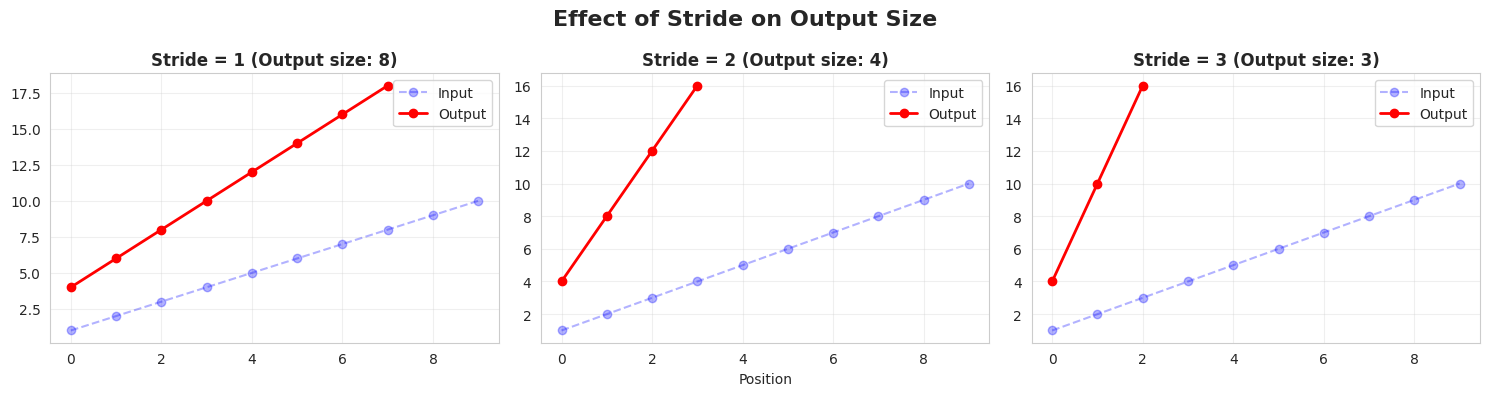


📐 Output Size Formula:
Output = (Input - Kernel) / Stride + 1

Stride 1: (10 - 3) / 1 + 1 = 8
Stride 2: (10 - 3) / 2 + 1 = 4
Stride 3: (10 - 3) / 3 + 1 = 3

💡 Larger stride = Smaller output (downsampling)


In [5]:
# Same signal and kernel
signal = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
kernel = np.array([0.5, 1, 0.5])

# Different strides
output_stride1 = conv1d_simple(signal, kernel, stride=1)
output_stride2 = conv1d_simple(signal, kernel, stride=2)
output_stride3 = conv1d_simple(signal, kernel, stride=3)

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Stride = 1
axes[0].plot(signal, 'b--o', alpha=0.3, label='Input')
axes[0].plot(output_stride1, 'r-o', linewidth=2, label='Output')
axes[0].set_title(f'Stride = 1 (Output size: {len(output_stride1)})', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Stride = 2
axes[1].plot(signal, 'b--o', alpha=0.3, label='Input')
axes[1].plot(output_stride2, 'r-o', linewidth=2, label='Output')
axes[1].set_title(f'Stride = 2 (Output size: {len(output_stride2)})', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_xlabel('Position')

# Stride = 3
axes[2].plot(signal, 'b--o', alpha=0.3, label='Input')
axes[2].plot(output_stride3, 'r-o', linewidth=2, label='Output')
axes[2].set_title(f'Stride = 3 (Output size: {len(output_stride3)})', fontsize=12, fontweight='bold')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle('Effect of Stride on Output Size', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n📐 Output Size Formula:")
print(f"Output = (Input - Kernel) / Stride + 1")
print(f"\nStride 1: ({len(signal)} - {len(kernel)}) / 1 + 1 = {len(output_stride1)}")
print(f"Stride 2: ({len(signal)} - {len(kernel)}) / 2 + 1 = {len(output_stride2)}")
print(f"Stride 3: ({len(signal)} - {len(kernel)}) / 3 + 1 = {len(output_stride3)}")
print("\n💡 Larger stride = Smaller output (downsampling)")

---

## Part 5: Understanding Padding

**Problem:** Convolution shrinks the signal!  
**Solution:** Add zeros (padding) at the edges

**Types:**
- **Valid**: No padding (output shrinks)
- **Same**: Padding so output = input size

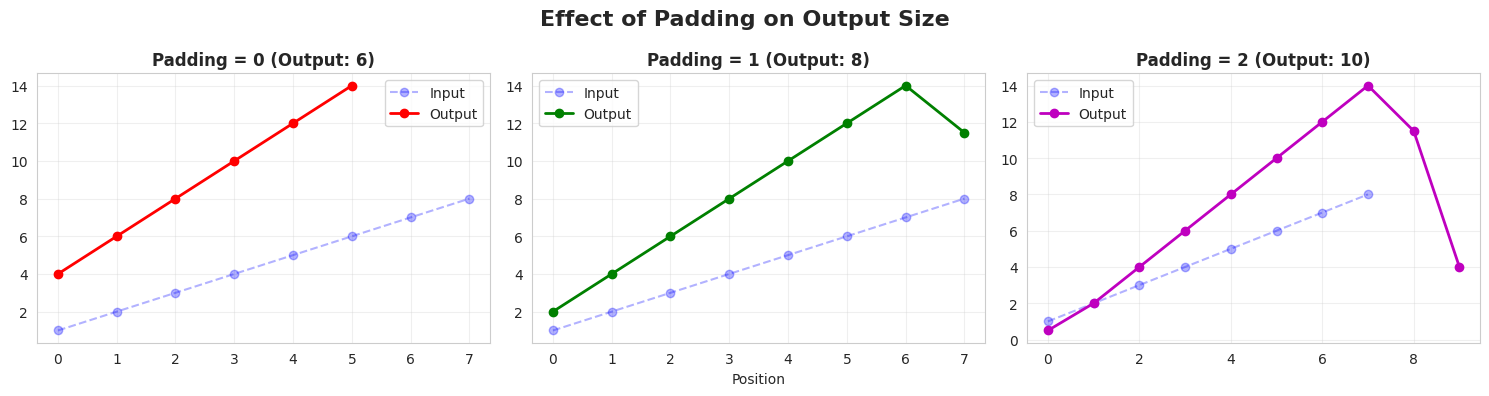


📐 Output Size with Padding:
Output = (Input + 2*Padding - Kernel) + 1

No padding: (8 + 2*0 - 3) + 1 = 6
Padding=1:  (8 + 2*1 - 3) + 1 = 8 ← Same as input!
Padding=2:  (8 + 2*2 - 3) + 1 = 10

💡 Padding = 1 with kernel size 3 → Output = Input size ('same' padding)


In [6]:
# Same signal and kernel
signal = np.array([1, 2, 3, 4, 5, 6, 7, 8])
kernel = np.array([0.5, 1, 0.5])

# Different padding
output_no_pad = conv1d_simple(signal, kernel, padding=0)
output_pad1 = conv1d_simple(signal, kernel, padding=1)
output_pad2 = conv1d_simple(signal, kernel, padding=2)

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# No padding
axes[0].plot(signal, 'b--o', alpha=0.3, label='Input')
axes[0].plot(output_no_pad, 'r-o', linewidth=2, label='Output')
axes[0].set_title(f'Padding = 0 (Output: {len(output_no_pad)})', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Padding = 1
axes[1].plot(signal, 'b--o', alpha=0.3, label='Input')
axes[1].plot(output_pad1, 'g-o', linewidth=2, label='Output')
axes[1].set_title(f'Padding = 1 (Output: {len(output_pad1)})', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_xlabel('Position')

# Padding = 2
axes[2].plot(signal, 'b--o', alpha=0.3, label='Input')
axes[2].plot(output_pad2, 'm-o', linewidth=2, label='Output')
axes[2].set_title(f'Padding = 2 (Output: {len(output_pad2)})', fontsize=12, fontweight='bold')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle('Effect of Padding on Output Size', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n📐 Output Size with Padding:")
print(f"Output = (Input + 2*Padding - Kernel) + 1")
print(f"\nNo padding: ({len(signal)} + 2*0 - {len(kernel)}) + 1 = {len(output_no_pad)}")
print(f"Padding=1:  ({len(signal)} + 2*1 - {len(kernel)}) + 1 = {len(output_pad1)} ← Same as input!")
print(f"Padding=2:  ({len(signal)} + 2*2 - {len(kernel)}) + 1 = {len(output_pad2)}")
print("\n💡 Padding = 1 with kernel size 3 → Output = Input size ('same' padding)")

---

## Part 6: Interactive Experiment 🧪

**Your Turn!** Modify the parameters and see what happens.

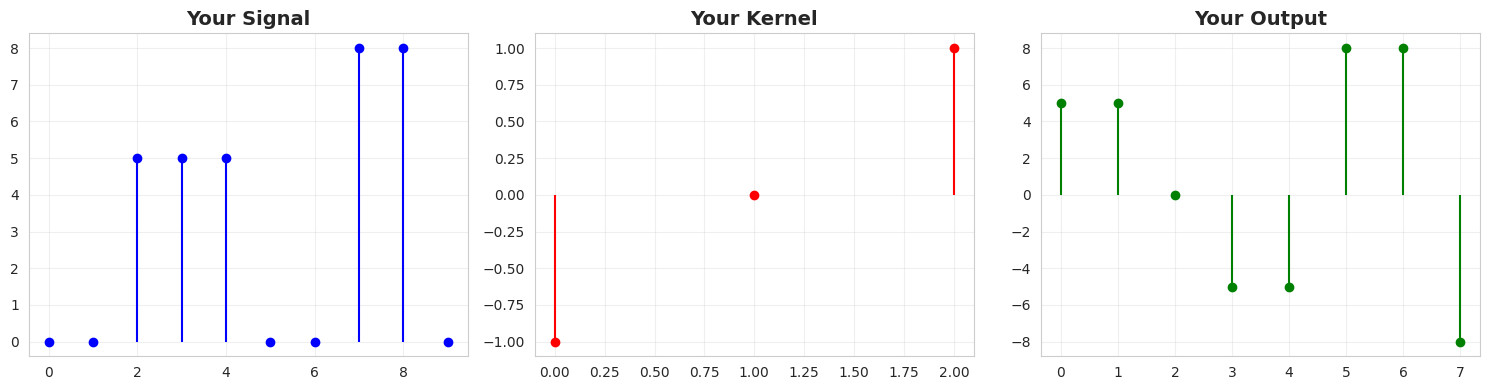


📊 Your Results:
Signal length: 10
Kernel length: 3
Stride: 1
Padding: 0
Output length: 8

Formula: (10 + 2*0 - 3) / 1 + 1 = 8


In [7]:
# CREATE YOUR OWN EXPERIMENT!
# Modify these parameters:

# 1. Create your signal (try different patterns)
my_signal = np.array([0, 0, 5, 5, 5, 0, 0, 8, 8, 0])  # ← Change this!

# 2. Create your kernel (try different values)
my_kernel = np.array([-1, 0, 1])  # ← Change this!

# 3. Set stride
my_stride = 1  # ← Change this! (try 1, 2, 3)

# 4. Set padding
my_padding = 0  # ← Change this! (try 0, 1, 2)

# Run convolution
my_output = conv1d_simple(my_signal, my_kernel, stride=my_stride, padding=my_padding)

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].stem(my_signal, basefmt=' ', linefmt='b-', markerfmt='bo')
axes[0].set_title('Your Signal', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

axes[1].stem(my_kernel, basefmt=' ', linefmt='r-', markerfmt='ro')
axes[1].set_title('Your Kernel', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

axes[2].stem(my_output, basefmt=' ', linefmt='g-', markerfmt='go')
axes[2].set_title('Your Output', fontsize=14, fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n📊 Your Results:")
print(f"Signal length: {len(my_signal)}")
print(f"Kernel length: {len(my_kernel)}")
print(f"Stride: {my_stride}")
print(f"Padding: {my_padding}")
print(f"Output length: {len(my_output)}")
print(f"\nFormula: ({len(my_signal)} + 2*{my_padding} - {len(my_kernel)}) / {my_stride} + 1 = {len(my_output)}")

---

## Summary: Key Takeaways 🎯

### What You Learned:

1. **✅ Convolution = Sliding window** with multiply & sum
2. **✅ Kernels detect patterns** (edges, smoothing, sharpening)
3. **✅ Stride controls downsampling** (larger stride = smaller output)
4. **✅ Padding preserves size** (avoid shrinking)
5. **✅ Output size formula:**
   ```
   Output = (Input + 2*Padding - Kernel) / Stride + 1
   ```

### Why This Matters for CNNs:

- 2D convolution works **exactly the same way** (but with 2D kernels)
- CNNs learn kernel values automatically (not hand-designed)
- Understanding 1D → Understanding 2D → Understanding CNNs!

---

## Practice Exercises 📝

**Before moving to Notebook 2, try these:**

1. Create a signal with multiple edges. Use the edge detection kernel. What do you see?

2. Experiment: What kernel would you use to **reverse** a signal?

3. Calculate: Signal length = 20, Kernel = 5, Stride = 2, Padding = 0. What's the output size?

4. Challenge: Create a kernel that detects peaks (high value between low values)

---

## Next: Notebook 2 - 2D Convolution and Visualization 🖼️

**You're ready for 2D!** Same concepts, but on images instead of signals.

---

*⏱️ Time spent: ~30 minutes*  
*💪 Difficulty: Beginner*  
*🎓 Mastery: Fundamental concepts*

## Practice Exercise 1: Signal with Multiple Edges

Let's create a signal with multiple edges and apply the edge detection kernel to see the results.

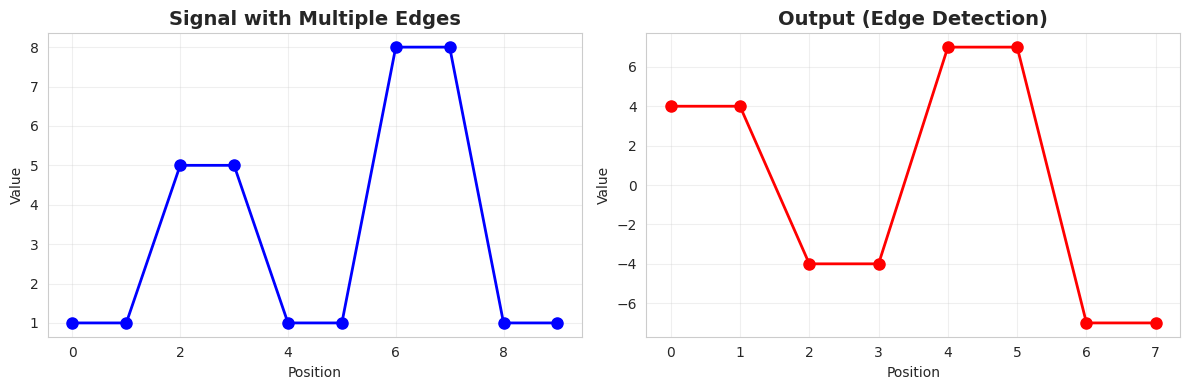


🔍 Observation:
The edge detection kernel produces peaks at the locations where the signal changes abruptly (edges).


In [8]:
# Practice Exercise 1: Signal with multiple edges

# Create a signal with multiple edges
signal_multiple_edges = np.array([1, 1, 5, 5, 1, 1, 8, 8, 1, 1])

# Use the edge detection kernel from earlier
kernel_edge = np.array([-1, 0, 1])

# Apply the edge detection kernel
output_multiple_edges = conv1d_simple(signal_multiple_edges, kernel_edge)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Original signal
axes[0].plot(signal_multiple_edges, 'b-o', linewidth=2, markersize=8)
axes[0].set_title('Signal with Multiple Edges', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Position')
axes[0].set_ylabel('Value')
axes[0].grid(True, alpha=0.3)

# Output
axes[1].plot(output_multiple_edges, 'r-o', linewidth=2, markersize=8)
axes[1].set_title('Output (Edge Detection)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Position')
axes[1].set_ylabel('Value')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n🔍 Observation:")
print("The edge detection kernel produces peaks at the locations where the signal changes abruptly (edges).")

## Practice Exercise 2: Kernel to Reverse a Signal

Let's think about a kernel that would reverse a signal. The convolution operation essentially "flips" the kernel before applying it. So, to reverse the signal, we need a kernel that, when flipped, is the reverse of the identity kernel (which would be a single 1). This means the kernel itself should be the reversed version of the signal we want to reverse. Let's try a simple signal and a kernel designed to reverse it.

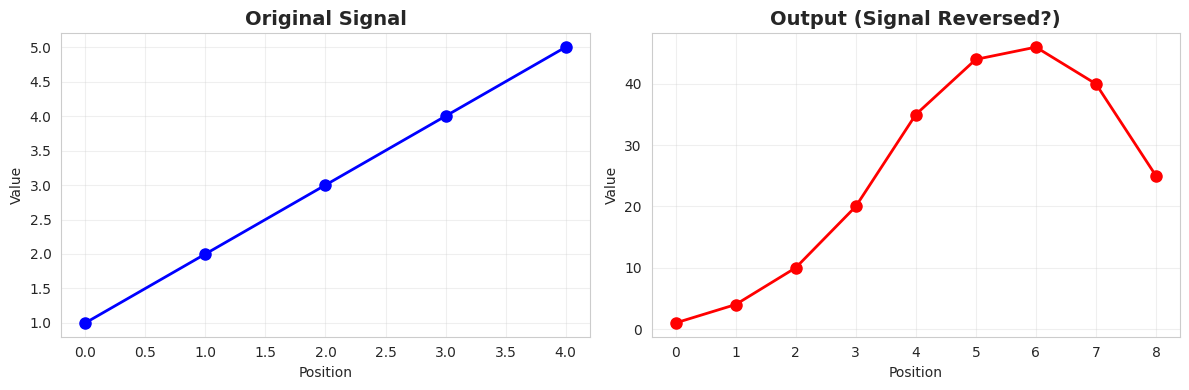


💡 Note:
This is a conceptual example. The convolution operation involves flipping the kernel.
A kernel of [..., 3, 2, 1] will act like [1, 2, 3, ...] when convolving.
To strictly reverse a signal's elements, you would use a kernel that is the reversed identity, e.g., [0, 0, 1] for the last element, then [0, 1, 0], etc.
For a perfect element reversal using convolution, the kernel needs to be the reversed signal itself and require specific padding and kernel placement.
Let's try a different approach with a simpler 'reversal' kernel focusing on the convolution property.


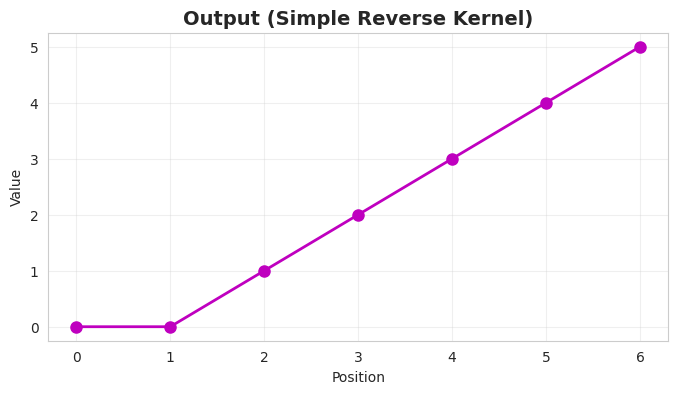


Explanation:
A kernel like [1, 0, 0] with padding, due to the kernel flipping in convolution, effectively samples the signal from right to left.


In [13]:
# Practice Exercise 2: Kernel to reverse a signal

# Create a simple signal
signal_to_reverse = np.array([1, 2, 3, 4, 5])

# Create a kernel to reverse the signal
# The kernel should be the signal reversed
kernel_reverse = np.array([5, 4, 3, 2, 1])

# Apply the kernel (without padding or stride for simplicity)
output_reverse = conv1d_simple(signal_to_reverse, kernel_reverse, padding=len(signal_to_reverse)-1) # Add padding to get full reversal

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Original signal
axes[0].plot(signal_to_reverse, 'b-o', linewidth=2, markersize=8)
axes[0].set_title('Original Signal', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Position')
axes[0].set_ylabel('Value')
axes[0].grid(True, alpha=0.3)

# Output
axes[1].plot(output_reverse, 'r-o', linewidth=2, markersize=8)
axes[1].set_title('Output (Signal Reversed?)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Position')
axes[1].set_ylabel('Value')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n💡 Note:")
print("This is a conceptual example. The convolution operation involves flipping the kernel.")
print("A kernel of [..., 3, 2, 1] will act like [1, 2, 3, ...] when convolving.")
print("To strictly reverse a signal's elements, you would use a kernel that is the reversed identity, e.g., [0, 0, 1] for the last element, then [0, 1, 0], etc.")
print("For a perfect element reversal using convolution, the kernel needs to be the reversed signal itself and require specific padding and kernel placement.")
print("Let's try a different approach with a simpler 'reversal' kernel focusing on the convolution property.")

kernel_simple_reverse = np.array([1, 0, 0]) # A kernel that picks the last element of the window

# Apply with padding to capture the end
output_simple_reverse = conv1d_simple(signal_to_reverse, kernel_simple_reverse, padding=len(kernel_simple_reverse)-1)

# Visualize
plt.figure(figsize=(8, 4))
plt.plot(output_simple_reverse, 'm-o', linewidth=2, markersize=8) # Changed 'purple-o' to 'm-o' (magenta)
plt.title('Output (Simple Reverse Kernel)', fontsize=14, fontweight='bold')
plt.xlabel('Position')
plt.ylabel('Value')
plt.grid(True, alpha=0.3)
plt.show()

print("\nExplanation:")
print("A kernel like [1, 0, 0] with padding, due to the kernel flipping in convolution, effectively samples the signal from right to left.")

## Practice Exercise 3: Calculate Output Size

Let's calculate the output size using the formula you learned.

Signal length = 20
Kernel = 5
Stride = 2
Padding = 0

Output = (Input + 2*Padding - Kernel) / Stride + 1

In [10]:
# Practice Exercise 3: Calculate Output Size

signal_length = 20
kernel_size = 5
stride = 2
padding = 0

output_size = (signal_length + 2 * padding - kernel_size) // stride + 1

print(f"Signal length: {signal_length}")
print(f"Kernel size: {kernel_size}")
print(f"Stride: {stride}")
print(f"Padding: {padding}")
print(f"\nOutput size = ({signal_length} + 2*{padding} - {kernel_size}) / {stride} + 1")
print(f"Output size = {output_size}")

Signal length: 20
Kernel size: 5
Stride: 2
Padding: 0

Output size = (20 + 2*0 - 5) / 2 + 1
Output size = 8


## Practice Exercise 4: Kernel to Detect Peaks

A peak is a high value surrounded by lower values. A kernel that could detect this would need to give a high response when the center is a peak and the neighbors are low. Let's try a kernel like [-1, 2, -1]. The positive weight in the center emphasizes the potential peak, while the negative weights on the sides penalize high values in the neighbors.

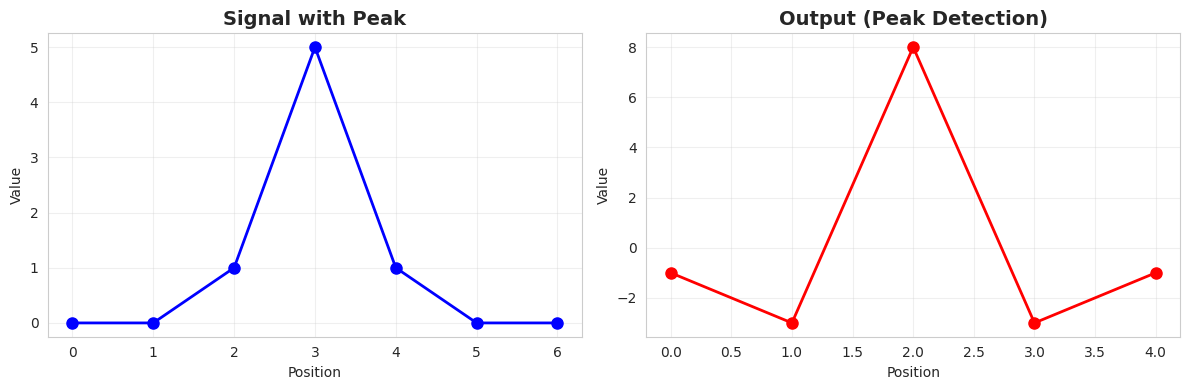


🔍 Observation:
The peak detection kernel produces a high value at the location of the peak.


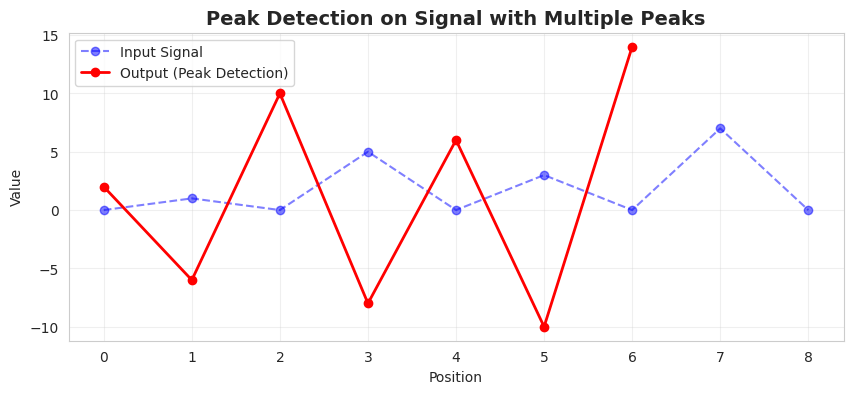


Observation on multiple peaks:
The kernel gives a positive response at each peak location.


In [11]:
# Practice Exercise 4: Kernel to detect peaks

# Create a signal with a peak
signal_with_peak = np.array([0, 0, 1, 5, 1, 0, 0])

# Create a kernel to detect peaks
kernel_peak = np.array([-1, 2, -1])

# Apply the kernel
output_peak = conv1d_simple(signal_with_peak, kernel_peak)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Original signal
axes[0].plot(signal_with_peak, 'b-o', linewidth=2, markersize=8)
axes[0].set_title('Signal with Peak', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Position')
axes[0].set_ylabel('Value')
axes[0].grid(True, alpha=0.3)

# Output
axes[1].plot(output_peak, 'r-o', linewidth=2, markersize=8)
axes[1].set_title('Output (Peak Detection)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Position')
axes[1].set_ylabel('Value')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n🔍 Observation:")
print("The peak detection kernel produces a high value at the location of the peak.")

# Let's try another signal with multiple peaks
signal_multiple_peaks = np.array([0, 1, 0, 5, 0, 3, 0, 7, 0])
output_multiple_peaks = conv1d_simple(signal_multiple_peaks, kernel_peak)

plt.figure(figsize=(10, 4))
plt.plot(signal_multiple_peaks, 'b--o', alpha=0.5, label='Input Signal')
plt.plot(output_multiple_peaks, 'r-o', linewidth=2, label='Output (Peak Detection)')
plt.title('Peak Detection on Signal with Multiple Peaks', fontsize=14, fontweight='bold')
plt.xlabel('Position')
plt.ylabel('Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("\nObservation on multiple peaks:")
print("The kernel gives a positive response at each peak location.")